# Final NIFTY Closing-Price Analysis

This final notebook preserves the original project's trend and moving-average ideas
while correcting its validation: future dates are never mixed into training data.
This is educational market analysis, not investment advice.

## 1. Load and inspect the included data

Date ordering is the key integrity requirement for time-series work, so we parse
dates and inspect the timeline before creating any forecast features.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from nifty_model import FEATURE_COLUMNS, chronological_split, create_features, evaluate_forecast

raw = pd.read_csv(Path("NSEI.csv"))
raw["Date"] = pd.to_datetime(raw["Date"])
print(f"Rows: {len(raw):,}; period: {raw.Date.min():%Y-%m-%d} to {raw.Date.max():%Y-%m-%d}")
raw.head()

Rows: 3,872; period: 2008-01-01 to 2023-09-04


,Date,Open,High,Low,Close,Adj Close,Volume
0,2008-01-01,6136.750000,6165.350098,6109.850098,6144.350098,6144.350098,0.0
1,2008-01-02,6144.700195,6197.000000,6060.850098,6179.399902,6179.399902,0.0
2,2008-01-03,6184.250000,6230.149902,6126.399902,6178.549805,6178.549805,0.0
3,2008-01-04,6179.100098,6300.049805,6179.100098,6274.299805,6274.299805,0.0
4,2008-01-07,6271.000000,6289.799805,6193.350098,6279.100098,6279.100098,0.0


## 2. Original trend-analysis idea, retained

The original notebook visualized closing-price movement. This version retains that
useful view and makes the date axis and data scope explicit.

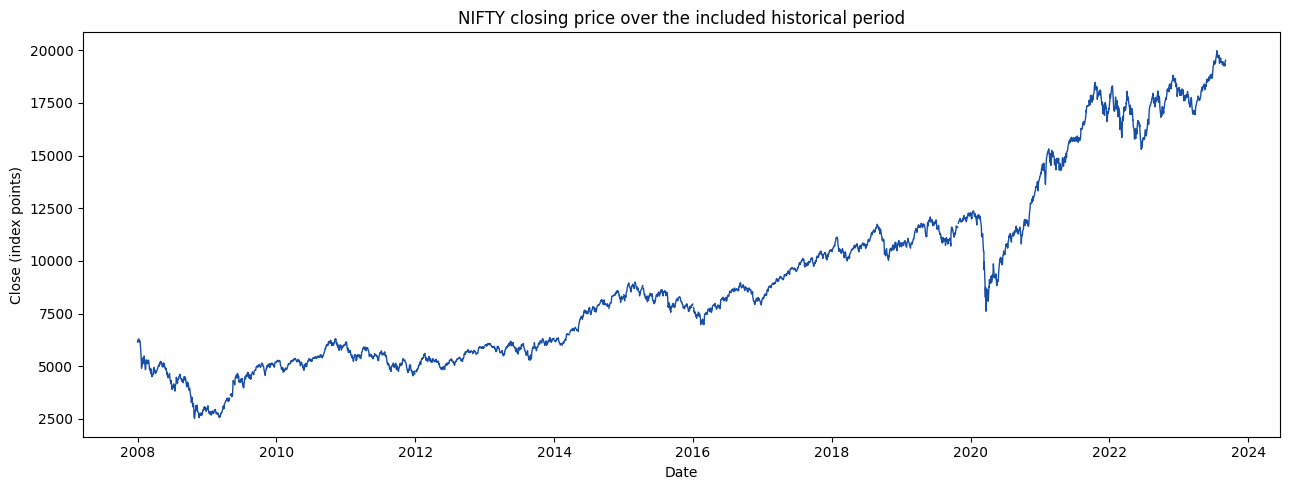

In [2]:
plt.figure(figsize=(13, 5))
plt.plot(raw["Date"], raw["Close"], color="#174ea6", linewidth=1)
plt.title("NIFTY closing price over the included historical period")
plt.xlabel("Date")
plt.ylabel("Close (index points)")
plt.tight_layout()
plt.show()

## 3. Create features without peeking ahead

Every feature is shifted by one day. The close on day *t* is the target; neither
it nor a moving average containing it is allowed into that row's inputs.

In [3]:
featured = create_features(raw)
featured[["Date", *FEATURE_COLUMNS, "target_close"]].head()

,Date,prev_close,sma_5,sma_20,target_close
0,2008-01-29,5274.100098,5158.720020,5840.514990,5280.799805
1,2008-01-30,5280.799805,5235.020020,5797.337476,5167.600098
2,2008-01-31,5167.600098,5227.860059,5746.747486,5137.450195
3,2008-02-01,5137.450195,5248.660059,5694.692505,5317.250000
4,2008-02-04,5317.250000,5235.440039,5646.840015,5463.500000


## 4. Chronological holdout evaluation

The earliest 80% of observations train the model. The latest 20% test it. This
mimics how a forecast is made in practice: the future is unavailable at training.

In [4]:
train, test = chronological_split(featured, test_fraction=0.2)
model = Pipeline([("scale", StandardScaler()), ("model", LinearRegression())])
model.fit(train[FEATURE_COLUMNS], train["target_close"])
predictions = model.predict(test[FEATURE_COLUMNS])
metrics = evaluate_forecast(test["target_close"], predictions)
pd.DataFrame([metrics], index=["Chronological holdout"]).round(3)

,mae,rmse,mape
Chronological holdout,119.364,157.863,0.71


## 5. Actual versus predicted prices

This plot shows exactly where the model follows or misses holdout movements. A low
percentage error does not establish a tradable strategy; it is only a historical
point-forecast measurement.

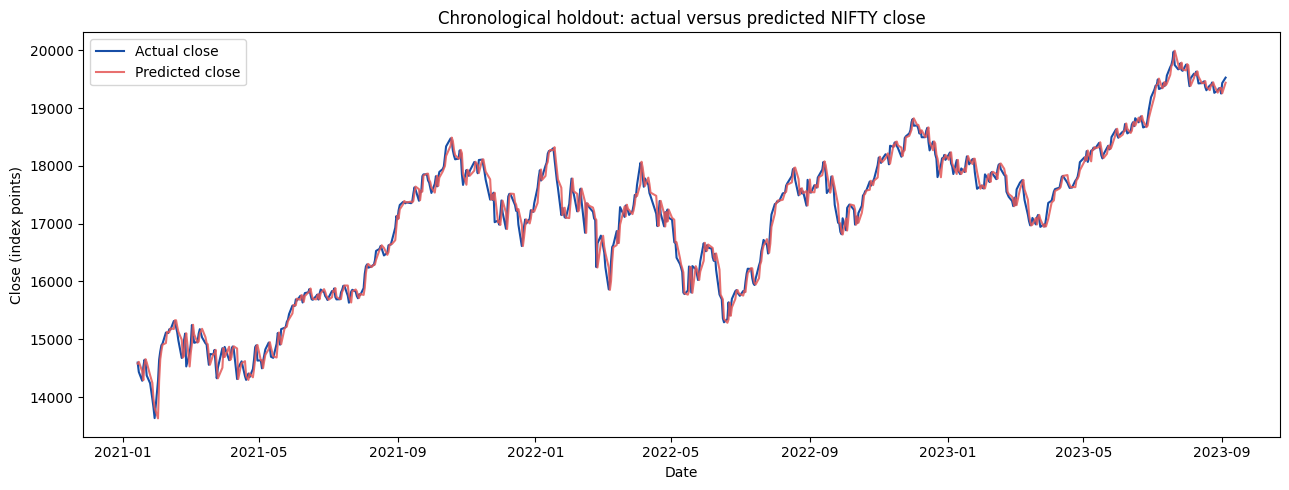

In [5]:
plt.figure(figsize=(13, 5))
plt.plot(test["Date"], test["target_close"], label="Actual close", color="#174ea6")
plt.plot(test["Date"], predictions, label="Predicted close", color="#e45756", alpha=.85)
plt.title("Chronological holdout: actual versus predicted NIFTY close")
plt.xlabel("Date")
plt.ylabel("Close (index points)")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Limits and next steps

The included data ends in September 2023. The model omits news, macroeconomic
events, transaction costs, risk management, and regime changes. Future work should
use walk-forward validation, compare naive persistence, and evaluate an entire
strategy—not just one-day price error.